## 回归系数森林图

In [4]:
import pandas as pd
import numpy as np

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# 读取数据
amr_path = r"C:\Users\lunch\Downloads\amr_rate.csv"
climate_path = r"C:\Users\lunch\Downloads\climate_social_eco.csv"

df_amr = pd.read_csv(amr_path)
df_x = pd.read_csv(climate_path)

def rename_key(df):
    m={}
    for c in df.columns:
        s = str(c).strip()
        if s.lower() in ["province","省份"]: m[c] = "Province"
        if s.lower() in ["year","年份"] or s == "YEAR": m[c] = "Year"
    return df.rename(columns=m)

df_amr = rename_key(df_amr)
df_x = rename_key(df_x)

print(df_amr.shape, df_x.shape)

# 合并 AMR + 气候/污染/社会经济
## 这里假设 Province + Year 是共同键（前面就是这么做的？）

df = pd.merge(
    df_amr,
    df_x,
    on=["Province", "Year"],
    how="inner"
)

print("Merged shape:", df.shape)
# 构造 AMR_AGG_z
amr_cols = [
    'MRCNS','VREFS','VREFM','PRSP','ERSP',
    '3GCRKP','MRSA','3GCREC','CREC',
    'QREC','CRPA','CRKP','CRAB'
]

amr_cols = [c for c in amr_cols if c in df.columns]

if "AMR_AGG_z" not in df.columns:
    amr_z = df[amr_cols].apply(
        lambda x: (x - x.mean()) / x.std(),
        axis=0
    )
    df["AMR_AGG_z"] = amr_z.mean(axis=1)
    print("✅ AMR_AGG_z created")
else:
    print("✅ AMR_AGG_z already exists")
# 选择指定的 9 个解释变量

X_vars = [
    "主要城市平均气温",
    "主要城市降水量",
    "R1xday",
    "PM2.5",
    "医疗水平",
    "GDP",
    "城市用水普及率",
    "生活垃圾无害化处理率",
    "抗菌药物使用强度"
]

# 确保列存在
X_vars = [c for c in X_vars if c in df.columns]
print("X used:", X_vars)
# 构造 Panel 数据结构（关键一步）
df = df.set_index(["Province", "Year"])
# 准备回归数据（自动处理缺失）

Y = df["AMR_AGG_z"]
X = df[X_vars]

# 删除缺失
data = pd.concat([Y, X], axis=1).dropna()

Y = data["AMR_AGG_z"]
X = data[X_vars]

# PanelOLS 需要显式常数（但 FE 会吸收）
X = sm.add_constant(X)

print("Final N:", len(Y))
# 8｜双固定效应回归（省份 FE + 年份 FE）

model = PanelOLS(
    Y,
    X,
    entity_effects=True,   # 省份 FE
    time_effects=True      # 年份 FE
)

res = model.fit(
    cov_type="clustered",
    cluster_entity=True   # 按省份聚类稳健SE
)

print(res.summary)


(313, 15) (341, 31)
Merged shape: (310, 44)
✅ AMR_AGG_z created
X used: ['主要城市平均气温', '主要城市降水量', 'R1xday', 'PM2.5', '医疗水平', 'GDP', '城市用水普及率', '生活垃圾无害化处理率', '抗菌药物使用强度']
Final N: 239
                          PanelOLS Estimation Summary                           
Dep. Variable:              AMR_AGG_z   R-squared:                        0.0341
Estimator:                   PanelOLS   R-squared (Between):              0.1155
No. Observations:                 239   R-squared (Within):              -0.5095
Date:                Tue, Feb 03 2026   R-squared (Overall):             -0.0315
Time:                        23:08:59   Log-likelihood                    85.114
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.7573
Entities:                          30   P-value                           0.6560
Avg Obs:                       7.9667   Distribution:                   F(9,193)
Min Obs:  

In [1]:
# 中文字体（确保不再乱码）
import matplotlib.pyplot as plt
import matplotlib as mpl

def set_chinese_font():
    candidates = [
        "Microsoft YaHei", "SimHei", "PingFang SC", "Hiragino Sans GB",
        "Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei",
        "Arial Unicode MS"
    ]
    available = set([f.name for f in mpl.font_manager.fontManager.ttflist])
    for name in candidates:
        if name in available:
            plt.rcParams["font.sans-serif"] = [name]
            plt.rcParams["axes.unicode_minus"] = False
            print("Loaded font:", name)
            return
    plt.rcParams["axes.unicode_minus"] = False
    print("⚠️ 未找到常见中文字体，可能仍无法显示中文。建议安装：微软雅黑/思源黑体/Noto Sans CJK。")

set_chinese_font()


Loaded font: Microsoft YaHei


In [2]:
# 2 森林图函数（核心）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signif_star(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    return ""

def plot_fe_forest(
    res,
    rename_map=None,
    drop_const=True,
    title="双固定效应回归系数图（AMR_AGG_z）",
    xlabel="系数估计值（带 95% 置信区间）",
    out_png="AMR_AGG_z_FE_forest.png",
    out_pdf="AMR_AGG_z_FE_forest.pdf"
):
    # 提取结果
    params = res.params.copy()
    se = res.std_errors.copy()
    p = res.pvalues.copy()

    # 去掉常数项（FE模型一般不展示）
    if drop_const and "const" in params.index:
        params = params.drop("const")
        se = se.drop("const")
        p = p.drop("const")

    # CI
    ci_low = params - 1.96 * se
    ci_high = params + 1.96 * se

    df = pd.DataFrame({
        "var": params.index,
        "beta": params.values,
        "se": se.values,
        "p": p.values,
        "low": ci_low.values,
        "high": ci_high.values
    })

    # 重命名（中文变量名更好看）
    if rename_map is not None:
        df["var_label"] = df["var"].map(lambda x: rename_map.get(x, x))
    else:
        df["var_label"] = df["var"]

    # 加星号
    df["star"] = df["p"].apply(signif_star)

    # 按 |beta| 排序（更直观）；你也可以改成按类别顺序
    df = df.reindex(df["beta"].abs().sort_values(ascending=True).index).reset_index(drop=True)

    # 画图
    y = np.arange(len(df))
    fig_h = max(4.5, 0.55 * len(df) + 1.5)
    fig, ax = plt.subplots(figsize=(8.5, fig_h), dpi=200)

    ax.hlines(y=y, xmin=df["low"], xmax=df["high"], linewidth=2)
    ax.plot(df["beta"], y, "o", markersize=6)

    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels([f"{v}{s}" for v, s in zip(df["var_label"], df["star"])])
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    # x范围留白
    xmin = min(df["low"].min(), df["beta"].min())
    xmax = max(df["high"].max(), df["beta"].max())
    pad = 0.08 * (xmax - xmin + 1e-12)
    ax.set_xlim(xmin - pad, xmax + pad)

    # 右侧标注 beta (se)
    for i, row in df.iterrows():
        ax.text(
            xmax + pad * 0.05,
            i,
            f"{row['beta']:.4f} ({row['se']:.4f})",
            va="center",
            fontsize=9
        )

    ax.set_ylim(-1, len(df))
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.savefig(out_png, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)
    print("Saved:", out_pdf)
    return df


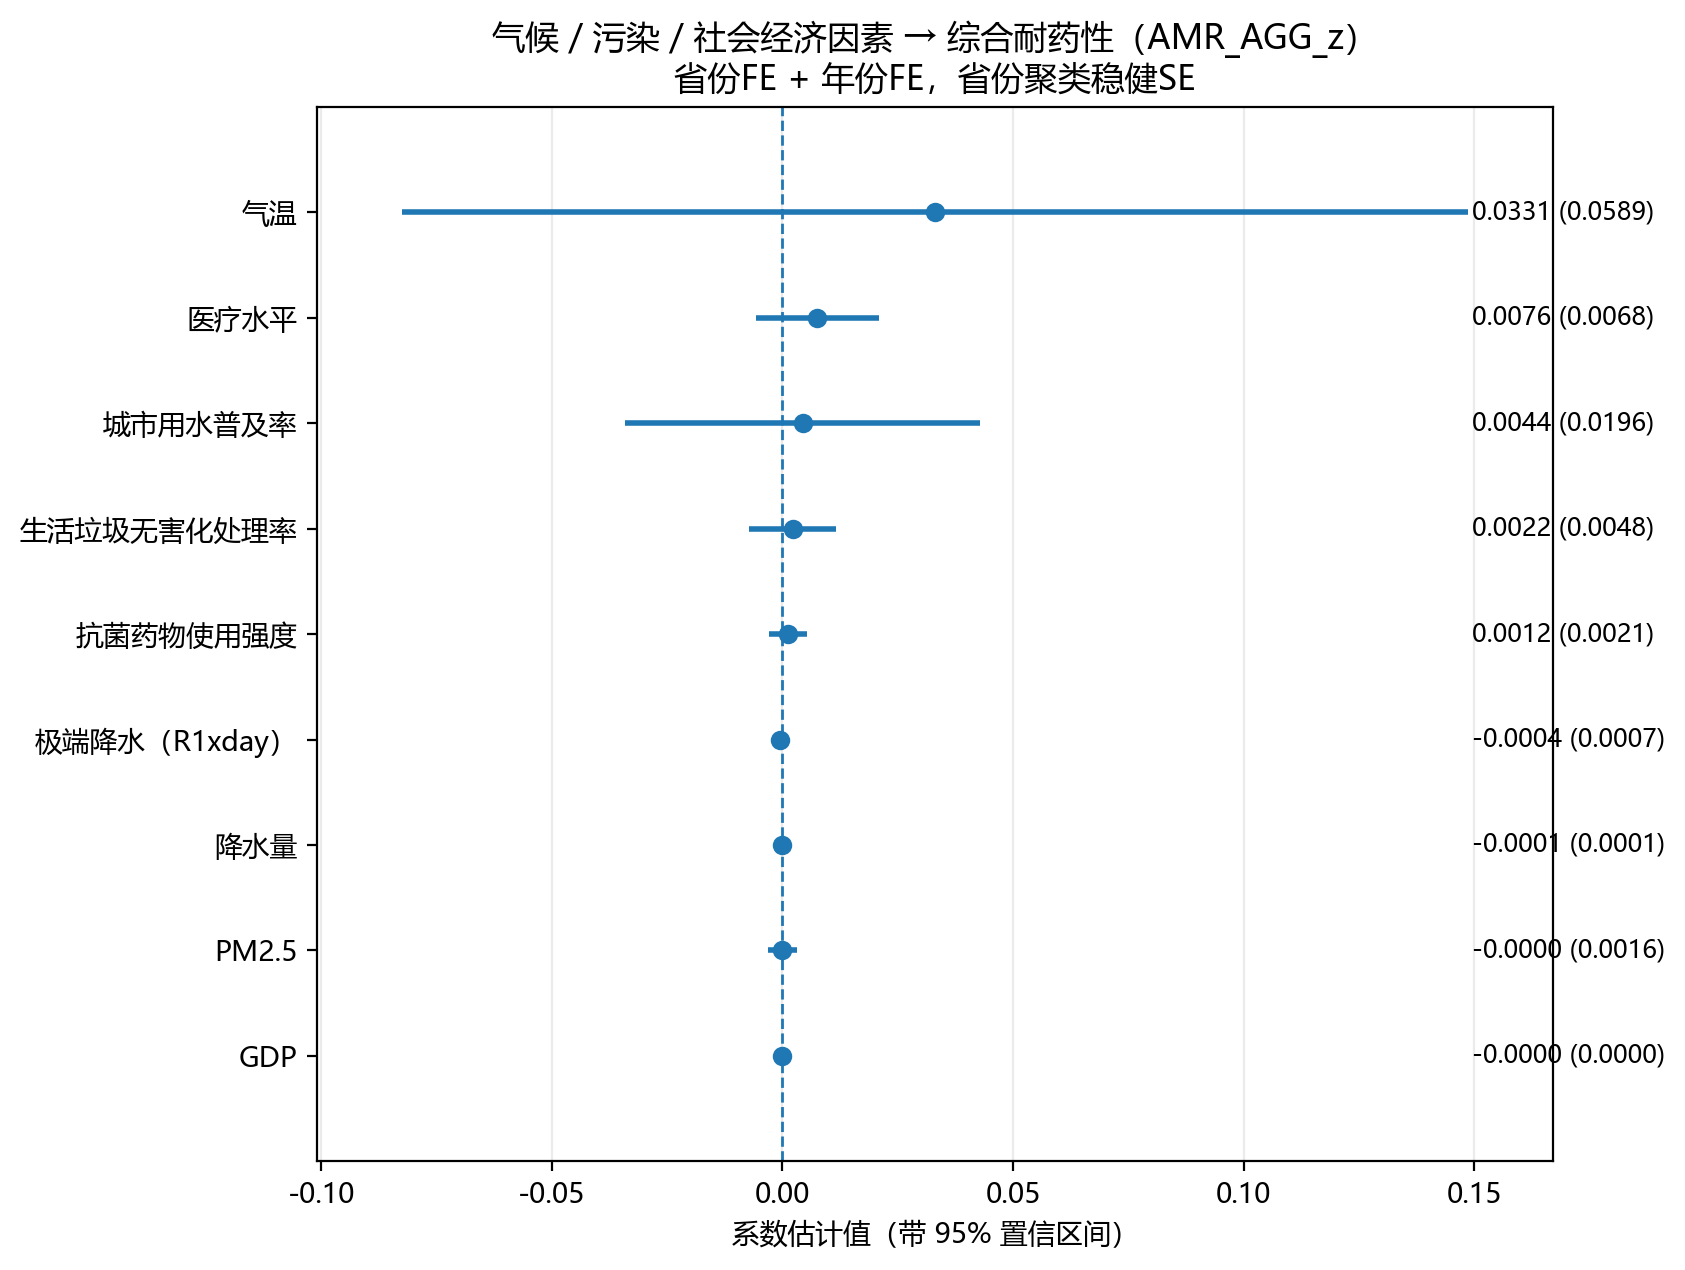

Saved: AMR_AGG_z_FE_forest.png
Saved: AMR_AGG_z_FE_forest.pdf


,var,beta,se,p,low,high,var_label,star
0,GDP,-7.405541e-07,0.000006,0.901917,-0.000013,0.000011,GDP,
1,PM2.5,-3.386000e-05,0.001610,0.983238,-0.003189,0.003121,PM2.5,
2,主要城市降水量,-7.545650e-05,0.000060,0.213686,-0.000194,0.000043,降水量,
3,R1xday,-4.362151e-04,0.000680,0.522014,-0.001769,0.000897,极端降水（R1xday）,
4,抗菌药物使用强度,1.201262e-03,0.002062,0.560922,-0.002841,0.005243,抗菌药物使用强度,


In [5]:
# Cell 3｜给变量重命名 + 出图保存
rename_map = {
    "主要城市平均气温": "气温",
    "主要城市降水量": "降水量",
    "R1xday": "极端降水（R1xday）",
    "PM2.5": "PM2.5",
    "医疗水平": "医疗水平",
    "GDP": "GDP",
    "城市用水普及率": "城市用水普及率",
    "生活垃圾无害化处理率": "生活垃圾无害化处理率",
    "抗菌药物使用强度": "抗菌药物使用强度",
}

forest_df = plot_fe_forest(
    res,
    rename_map=rename_map,
    title="气候 / 污染 / 社会经济因素 → 综合耐药性（AMR_AGG_z）\n省份FE + 年份FE，省份聚类稳健SE",
    out_png="AMR_AGG_z_FE_forest.png",
    out_pdf="AMR_AGG_z_FE_forest.pdf"
)

forest_df.head()
